**Dataset from KITTI**

In [1]:
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip
!unzip data_object_label_2.zip

Streaming output truncated to the last 5000 lines.
 extracting: training/label_2/001705.txt  
 extracting: training/label_2/000367.txt  
 extracting: training/label_2/006048.txt  
 extracting: training/label_2/005468.txt  
 extracting: training/label_2/007308.txt  
 extracting: training/label_2/001417.txt  
 extracting: training/label_2/006638.txt  
 extracting: training/label_2/002132.txt  
 extracting: training/label_2/002407.txt  
 extracting: training/label_2/007186.txt  
 extracting: training/label_2/004363.txt  
 extracting: training/label_2/005764.txt  
 extracting: training/label_2/003298.txt  
 extracting: training/label_2/002664.txt  
 extracting: training/label_2/002322.txt  
 extracting: training/label_2/005098.txt  
 extracting: training/label_2/007135.txt  
 extracting: training/label_2/001415.txt  
 extracting: training/label_2/000344.txt  
 extracting: training/label_2/005904.txt  
 extracting: training/label_2/007166.txt  
 extracting: training/label_2/000502.txt  
 ex

In [2]:
import os
print(os.listdir("training/label_2")[:5])

['003861.txt', '001919.txt', '006157.txt', '002767.txt', '000552.txt']


**Extract Dataset**

In [3]:
import os, pandas as pd, numpy as np

data = []
for file in os.listdir("training/label_2")[:500]:
    with open(f"training/label_2/{file}") as f:
        lines = f.readlines()

    dists = [float(l.split()[13]) for l in lines if l.split()[0] != "DontCare"]
    num = len(dists)

    min_d = min(dists) if dists else 100
    avg_d = np.mean(dists) if dists else 100

    risk = int(min_d < 5 or num > 10)

    data.append([num, min_d, avg_d, risk])

df = pd.DataFrame(data, columns=['num_objects','min_distance','avg_distance','collision_risk'])

print(df.head())

   num_objects  min_distance  avg_distance  collision_risk
0            4         42.30     57.322500               0
1            9          5.11     22.171111               0
2           16          1.69     22.373125               1
3            1          8.92      8.920000               0
4            1         13.37     13.370000               0


**EDA**

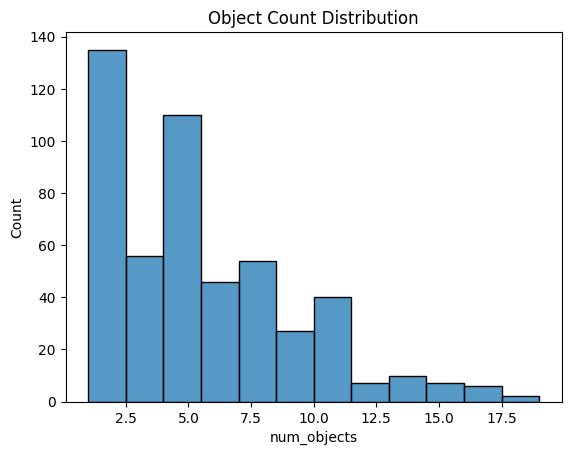

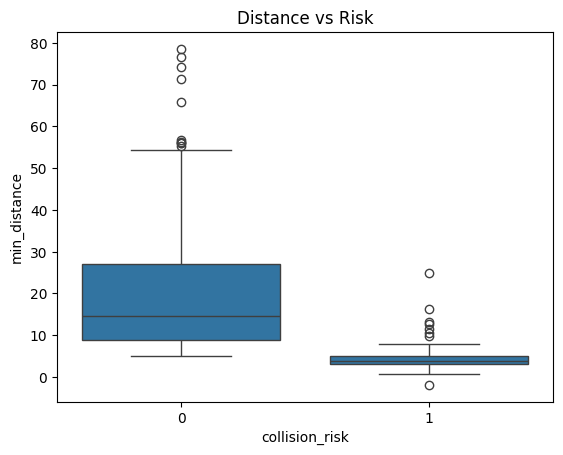

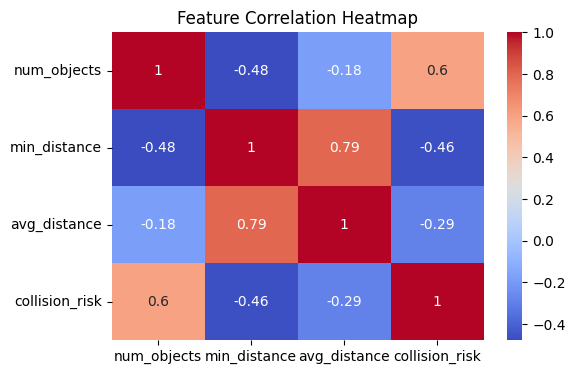

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['num_objects'])
plt.title("Object Count Distribution")
plt.show()

sns.boxplot(x='collision_risk', y='min_distance', data=df)
plt.title("Distance vs Risk")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

**Train Model**

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('collision_risk', axis=1)
y = df['collision_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

**Evaluate Model**

In [6]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.99
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        81
           1       0.95      1.00      0.97        19

    accuracy                           0.99       100
   macro avg       0.97      0.99      0.98       100
weighted avg       0.99      0.99      0.99       100



**Feature Importance**

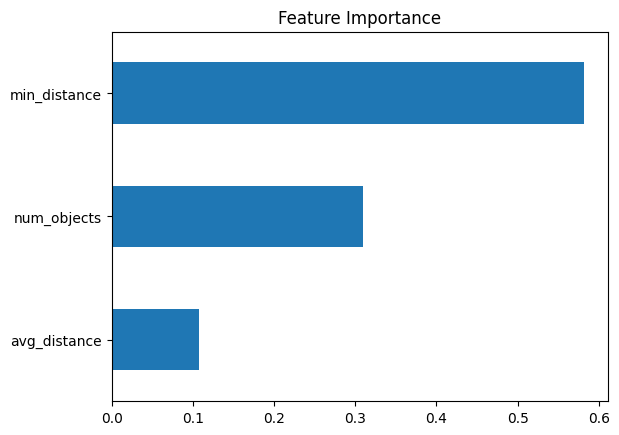

In [7]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

**Confusion Matrix**

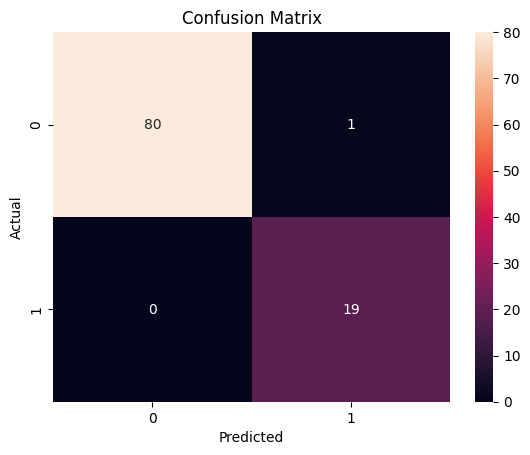

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**ROC Curve**

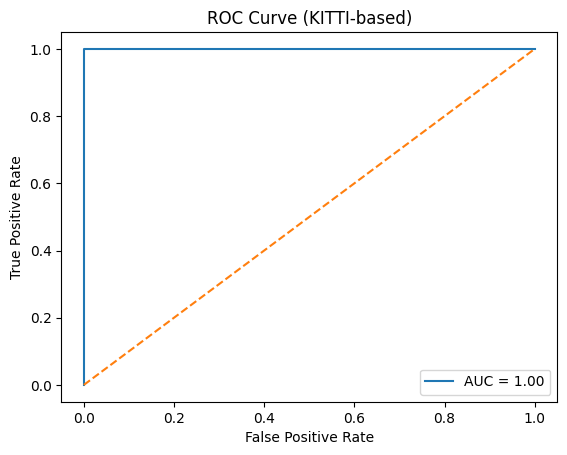

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (KITTI-based)")
plt.legend()
plt.show()

**Actual vs Predicted**

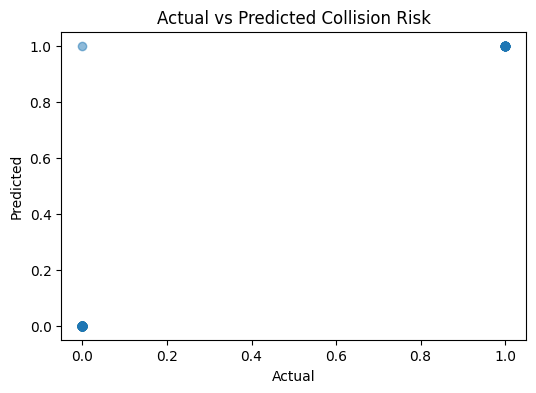

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Collision Risk")
plt.show()

**Testing**

In [11]:
import pandas as pd

test_cases = pd.DataFrame([
    [15, 3, 5],   # high risk
    [2, 50, 60]   # low risk
], columns=X.columns)

pred = model.predict(test_cases)

for i, p in enumerate(pred):
    print(f"Scenario {i+1}: {'HIGH RISK' if p==1 else 'LOW RISK'}")

Scenario 1: HIGH RISK
Scenario 2: LOW RISK


In [12]:
import pandas as pd

test_cases = pd.DataFrame([
    [20, 2, 4],    # Very close objects (critical emergency traffic)
    [8, 10, 15],   # Moderate traffic, medium distance
    [3, 80, 90],   # Almost empty road (safe)
    [25, 6, 8],    # Heavy traffic but manageable distance
    [12, 1, 3]     # Extremely dangerous (very close obstacle)
], columns=X.columns)

pred = model.predict(test_cases)

for i, p in enumerate(pred):
    print(f"Scenario {i+1}: {'HIGH RISK' if p==1 else 'LOW RISK'}")

Scenario 1: HIGH RISK
Scenario 2: LOW RISK
Scenario 3: LOW RISK
Scenario 4: HIGH RISK
Scenario 5: HIGH RISK


In [13]:
labels = [
    "Emergency Congestion",
    "Moderate Traffic",
    "Clear Road",
    "Urban Traffic",
    "Critical Obstacle"
]

for i, p in enumerate(pred):
    print(f"{labels[i]} → {'HIGH RISK' if p==1 else 'LOW RISK'}")

Emergency Congestion → HIGH RISK
Moderate Traffic → LOW RISK
Clear Road → LOW RISK
Urban Traffic → HIGH RISK
Critical Obstacle → HIGH RISK


**Taking first 10 datasets**

In [ ]:
y_pred = model.predict(X_test)

for i, p in enumerate(y_pred[:10]):  
    label = "Low Risk" if p == 0 else "High Risk"
    print(f"Sample {i+1}: {p} → {label}")

Sample 1: 0 → Low Risk
Sample 2: 0 → Low Risk
Sample 3: 1 → High Risk
Sample 4: 1 → High Risk
Sample 5: 0 → Low Risk
Sample 6: 0 → Low Risk
Sample 7: 1 → High Risk
Sample 8: 0 → Low Risk
Sample 9: 0 → Low Risk
Sample 10: 0 → Low Risk


In [15]:
test_cases = pd.DataFrame([
    [15, 3, 5],
    [2, 50, 60]
], columns=X.columns)

pred = model.predict(test_cases)

for i, p in enumerate(pred):
    label = "Low Risk" if p == 0 else "High Risk"
    print(f"Scenario {i+1}: {p} → {label}")

Scenario 1: 1 → High Risk
Scenario 2: 0 → Low Risk


**Summary**

In [16]:
print("Model Summary:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Features used:", list(X.columns))

Model Summary:
Accuracy: 0.99
Features used: ['num_objects', 'min_distance', 'avg_distance']
